# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [ ]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [ ]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [ ]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [ ]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

RuntimeError: Não foi possível consultar a API: <urlopen error timed out>

### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [ ]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

ValueError: Poucos registros válidos: confira a resposta da ANEEL

In [ ]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import ConfusionMatrixDisplay

In [15]:
dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
dados.head(20)

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar
5,404.80,-12.945833,-38.417778,Solar
6,1082.00,-22.815833,-47.059167,Solar
7,1.70,-27.447981,-48.501745,Solar
8,1.04,-22.172160,-47.337620,Solar
9,30.87,-2.474278,-43.574217,Solar


In [16]:
print("Linhas e colunas:", dados.shape)
print("\nValores ausentes:\n", dados.isna().sum())
print("\nQuantidade por classe:\n", dados["fonte"].value_counts())
dados.groupby("fonte")["potencia_kw"].describe()

Linhas e colunas: (3876, 4)

Valores ausentes:
 potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Quantidade por classe:
 fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
fonte,,,,,,,,
Eólica,1200.0,30782.769883,13800.597800,0.16,23100.0,29600.0,37200.0,105000.0
Hidráulica,1476.0,75809.158279,486419.578953,0.99,990.0,4000.0,17000.0,11233100.0
Solar,1200.0,11679.386733,18374.855154,0.26,1.0,1.0,28880.0,137480.0


# EXPLORAÇÃO

O conjunto tem 3.876 empreendimentos e 4 colunas. Não há valores ausentes. As classes estão relativamente equilibradas: 1.476 hidráulicas, 1.200 solares e 1.200 eólicas. A potência varia muito: as hidráulicas vão de usinas pequenas até usinas gigantes, enquanto as eólicas ficam numa faixa mais concentrada.

In [17]:
zeros = (dados["latitude"] == 0) & (dados["longitude"] == 0)
print("Linhas com coordenada (0,0):", zeros.sum())
dados = dados[~zeros]
print("Linhas após limpeza:", dados.shape[0])

Linhas com coordenada (0,0): 47
Linhas após limpeza: 3829


# LIMPEZA

Encontramos 47 linhas com latitude e longitude iguais a 0. Esse ponto fica no Oceano Atlântico, então consideramos que a coordenada estava ausente e removemos essas linhas.

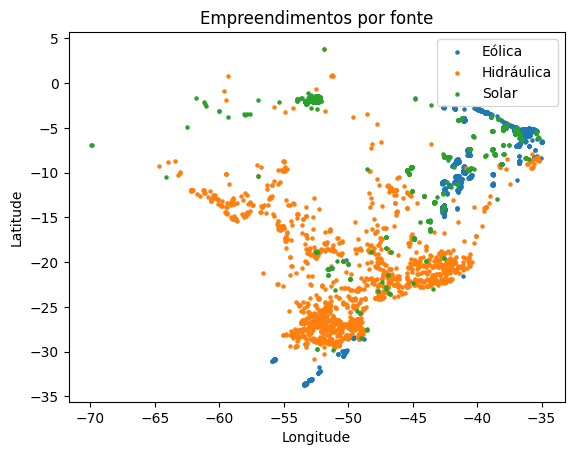

In [20]:
for fonte, grupo in dados.groupby("fonte"):
    plt.scatter(grupo["longitude"], grupo["latitude"], s=5, label=fonte)
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title("Empreendimentos por fonte"); plt.legend(); plt.show()

# MAPA

As eólicas se concentram no litoral do Nordeste e no Sul. As hidráulicas estão mais espalhadas pelo interior, e as solares aparecem em várias regiões. A localização ajuda a separar as classes, mas há regiões onde as fontes se misturam.

In [21]:
X = dados[["potencia_kw", "latitude", "longitude"]]
y = dados["fonte"]
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print("Treino:", X_treino.shape, "| Teste:", X_teste.shape)

Treino: (3063, 3) | Teste: (766, 3)


# DIVISÃO

Usamos 80% dos dados para treino e 20% para teste, com divisão estratificada para manter a mesma proporção de classes nos dois conjuntos. A semente foi fixada em 42 para que o resultado possa ser reproduzido.

In [22]:
modelos = {
    "Regressão Logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "KNN (k=5)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
}

resultados = []
previsoes = {}
for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    p = modelo.predict(X_teste)
    previsoes[nome] = p
    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_teste, p),
        "Precision (macro)": precision_score(y_teste, p, average="macro"),
        "Recall (macro)": recall_score(y_teste, p, average="macro"),
        "F1 (macro)": f1_score(y_teste, p, average="macro"),
    })

tabela_class = pd.DataFrame(resultados).round(3)
tabela_class

,Modelo,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Regressão Logística,0.830,0.837,0.829,0.826
1,KNN (k=5),0.960,0.960,0.959,0.959
2,Random Forest,0.977,0.977,0.976,0.977


### Escolha e comparação dos classificadores

Treinamos três classificadores de famílias diferentes, todos com a mesma divisão estratificada (80% treino / 20% teste, `random_state=42`):

- **Regressão Logística:** modelo linear simples, usado como referência. Como é sensível à escala das variáveis, aplicamos `StandardScaler` dentro de um pipeline, ajustado apenas com os dados de treino.
- **KNN (k=5):** classifica cada empreendimento pela classe dos 5 vizinhos mais próximos. Faz sentido para dados geográficos, pois usinas do mesmo tipo tendem a ficar próximas. Por usar distâncias, também recebeu padronização.
- **Random Forest (300 árvores):** conjunto de árvores de decisão capaz de capturar relações não lineares. Não precisa de padronização.

As métricas Precision, Recall e F1 foram calculadas com **média macro**, que dá o mesmo peso para as três classes. Escolhemos essa média porque as classes têm tamanhos parecidos e queremos avaliar o desempenho em cada fonte de forma igual.

| Modelo | Accuracy | F1 (macro) |
|---|---|---|
| Regressão Logística | 0,83 | 0,83 |
| KNN (k=5) | 0,96 | 0,96 |
| Random Forest | 0,98 | 0,98 |

O **Random Forest** teve o melhor desempenho em todas as métricas, seguido de perto pelo KNN. A Regressão Logística ficou bem atrás, o que indica que as fronteiras entre as classes não são lineares.

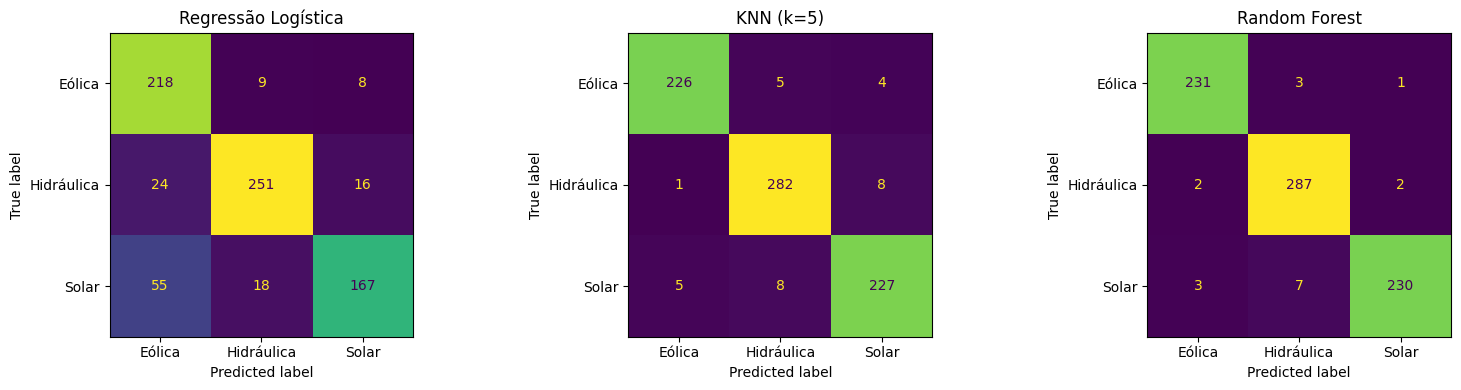

In [23]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 4))
for eixo, (nome, p) in zip(eixos, previsoes.items()):
    ConfusionMatrixDisplay.from_predictions(y_teste, p, ax=eixo, colorbar=False)
    eixo.set_title(nome)
plt.tight_layout(); plt.show()

### Interpretação das matrizes de confusão

**Classes mais confundidas:** na Regressão Logística, a maior confusão é entre **Solar e Eólica**: muitas usinas solares foram classificadas como eólicas. Isso acontece porque as duas fontes aparecem nas mesmas regiões (principalmente no Nordeste) e têm faixas de potência parecidas, e um modelo linear não consegue separá-las bem. No Random Forest e no KNN os erros são poucos, e os que restam aparecem principalmente entre Hidráulica e Solar.

**Modelo escolhido:** o **Random Forest**, por ter a maior acurácia e o maior F1 macro, com poucos erros em todas as classes.

**Cuidado com a acurácia alta:** um resultado acima de 95% deve ser visto com cautela. Empreendimentos do mesmo tipo costumam ficar muito próximos uns dos outros (ex.: parques eólicos com várias usinas vizinhas), e o conjunto tem algumas linhas duplicadas. Assim, o modelo pode estar "decorando" regiões em vez de aprender um padrão geral, e o desempenho tende a cair para empreendimentos em locais novos.

**Limitações de usar apenas potência e localização:**
- Uma usina solar e uma eólica de mesma potência podem estar na mesma cidade; essas três variáveis não descrevem a tecnologia em si.
- A potência outorgada é a potência autorizada, não a energia realmente gerada.
- A consulta trouxe no máximo 1.200 registros por tipo de geração, então a quantidade de exemplos de cada classe **não representa a participação das fontes na matriz energética brasileira**.
- O cadastro inclui empreendimentos em diferentes fases (em operação, em construção, planejados).

Para uma aplicação real, seriam necessárias outras informações, como dados de relevo, de recursos hídricos, de vento ou de irradiação da região.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

In [24]:
meteo = pd.read_csv(
    "https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/meteo_regressao_orange.csv",
    parse_dates=["data_hora"]).sort_values("data_hora")
print("Linhas e colunas:", meteo.shape)
print("\nValores ausentes:\n", meteo.isna().sum())
meteo.describe()

Linhas e colunas: (1001, 7)

Valores ausentes:
 data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,2025-05-16 11:59:59.999999744,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
min,2025-04-01 07:00:00,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,2025-04-23 15:00:00,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,2025-05-16 12:00:00,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,2025-06-08 09:00:00,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,2025-06-30 17:00:00,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000
std,NaN,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950


### Exploração dos dados meteorológicos

O conjunto tem **1.001 registros horários** e 7 colunas, cobrindo de 01/04/2025 a 30/06/2025, sempre entre 7h e 17h (hora local de Petrolina-PE). **Não há valores ausentes.**

- `data_hora`: identifica e ordena as observações; **não é usada como entrada**.
- `temperatura_c`: varia de 19,5 °C a 36,1 °C (média de 28,9 °C).
- `umidade_pct`: varia de 21% a 95% (média de 50,5%).
- `nuvens_pct`: ocupa toda a faixa de 0% a 100% (média de 55%), com muitos registros de céu totalmente encoberto.
- `vento_kmh`: varia de 2,3 a 30,1 km/h.
- `hora`: de 7 a 17.
- `radiacao_w_m2` (**alvo**): varia de 13 a 1.002 W/m², com média de 473 W/m².

Definimos **X** com as cinco entradas (`temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh`, `hora`) e **y** como `radiacao_w_m2`. A radiação não entra em X em nenhuma forma.

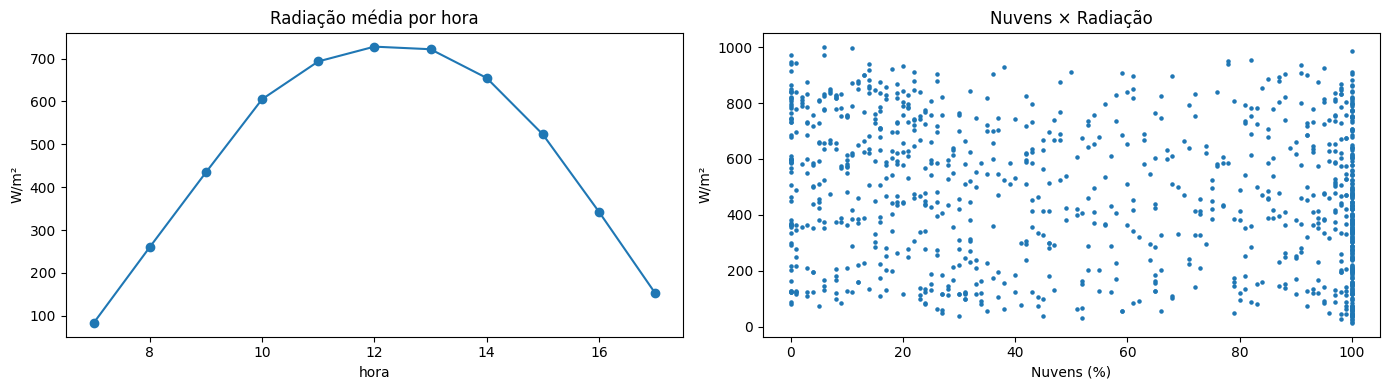

In [25]:
fig, eixos = plt.subplots(1, 2, figsize=(14, 4))
meteo.groupby("hora")["radiacao_w_m2"].mean().plot(marker="o", ax=eixos[0])
eixos[0].set_title("Radiação média por hora"); eixos[0].set_ylabel("W/m²")
eixos[1].scatter(meteo["nuvens_pct"], meteo["radiacao_w_m2"], s=5)
eixos[1].set_title("Nuvens × Radiação"); eixos[1].set_xlabel("Nuvens (%)"); eixos[1].set_ylabel("W/m²")
plt.tight_layout(); plt.show()

### Visualizações

**Radiação média por hora:** a radiação forma uma **curva em sino** ao longo do dia. Começa perto de 80 W/m² às 7h, atinge o pico de cerca de 730 W/m² entre 12h e 13h e cai para cerca de 150 W/m² às 17h. Isso reflete a altura do Sol no céu: quanto mais alto, mais radiação chega à superfície. A relação entre hora e radiação é forte, mas **não é linear** (sobe e depois desce).

**Nuvens × Radiação:** os pontos estão muito espalhados. Há horários com 100% de nuvens e radiação alta, e horários com céu limpo e radiação baixa. Sozinha, a cobertura de nuvens explica pouco, porque o efeito dela se mistura com o da hora (um céu limpo às 7h tem pouca radiação). Além disso, `cloud_cover` mede a cobertura **total**, incluindo nuvens altas e finas que bloqueiam pouco a luz do Sol.

In [26]:
entradas = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
corte = int(len(meteo) * 0.8)
treino, teste = meteo.iloc[:corte], meteo.iloc[corte:]
Xr_treino, yr_treino = treino[entradas], treino["radiacao_w_m2"]
Xr_teste, yr_teste = teste[entradas], teste["radiacao_w_m2"]
print("Treino:", treino["data_hora"].min(), "até", treino["data_hora"].max())
print("Teste: ", teste["data_hora"].min(), "até", teste["data_hora"].max())

Treino: 2025-04-01 07:00:00 até 2025-06-12 14:00:00
Teste:  2025-06-12 15:00:00 até 2025-06-30 17:00:00


### Divisão temporal

Mantivemos a ordem cronológica e **não embaralhamos** os dados:

- **Treino (80%):** 01/04/2025 07h até 12/06/2025 14h.
- **Teste (20%):** 12/06/2025 15h até 30/06/2025 17h.

Assim o modelo é avaliado em horas "futuras", que ele nunca viu, como aconteceria em uma aplicação real. Se embaralhássemos, horas vizinhas do mesmo dia (muito parecidas entre si) poderiam cair uma no treino e outra no teste, e o resultado ficaria otimista demais.

Um ponto de atenção: o teste cai no fim de junho, perto do inverno, quando a radiação máxima é menor que em abril. Ou seja, o modelo é testado em condições um pouco diferentes das que viu no treino.

In [27]:
regressores = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
}
res_reg, prev_reg = [], {}
for nome, modelo in regressores.items():
    modelo.fit(Xr_treino, yr_treino)
    p = modelo.predict(Xr_teste)
    prev_reg[nome] = p
    res_reg.append({"Modelo": nome,
                    "MAE (W/m²)": mean_absolute_error(yr_teste, p),
                    "MSE ((W/m²)²)": mean_squared_error(yr_teste, p),
                    "R²": r2_score(yr_teste, p)})
tabela_reg = pd.DataFrame(res_reg).round(3)
tabela_reg

,Modelo,MAE (W/m²),MSE ((W/m²)²),R²
0,Regressão Linear,145.205,30034.201,0.360
1,Árvore de Decisão,90.938,15127.027,0.678
2,Random Forest,66.399,7210.084,0.846


### Escolha e comparação dos regressores

Treinamos três regressores diferentes com a **mesma divisão temporal**:

- **Regressão Linear:** modelo simples que serve de referência; assume que cada entrada tem efeito linear sobre a radiação.
- **Árvore de Decisão (profundidade máxima 6):** divide os dados em faixas e consegue capturar relações não lineares. A profundidade foi limitada para evitar sobreajuste.
- **Random Forest (300 árvores):** média de várias árvores, mais estável e precisa que uma única árvore.

| Modelo | MAE (W/m²) | MSE ((W/m²)²) | R² |
|---|---|---|---|
| Regressão Linear | 145,2 | 30.034 | 0,360 |
| Árvore de Decisão | 90,9 | 15.127 | 0,678 |
| Random Forest | 66,4 | 7.210 | 0,846 |

O **Random Forest** foi o melhor nas três métricas: erra em média 66 W/m² e explica cerca de 85% da variação da radiação no período de teste. A Regressão Linear teve o pior desempenho, com erro médio mais que o dobro do Random Forest.

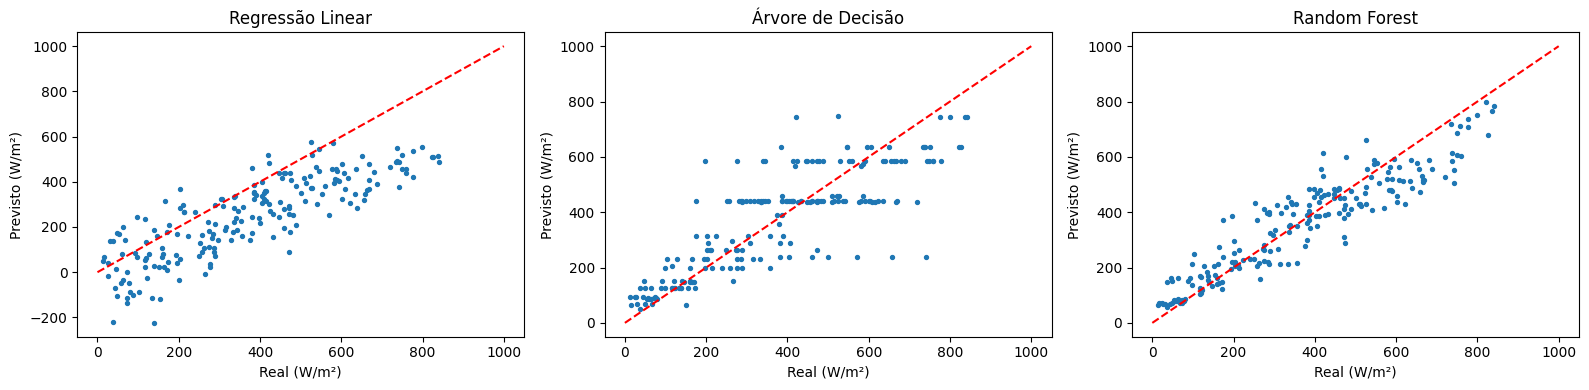

In [28]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 4))
for eixo, (nome, p) in zip(eixos, prev_reg.items()):
    eixo.scatter(yr_teste, p, s=8)
    eixo.plot([0, 1000], [0, 1000], "r--")
    eixo.set_title(nome); eixo.set_xlabel("Real (W/m²)"); eixo.set_ylabel("Previsto (W/m²)")
plt.tight_layout(); plt.show()

### Real × Previsto

Quanto mais perto da linha vermelha tracejada, melhor a previsão.

- **Regressão Linear:** os pontos ficam espalhados e o modelo **subestima** as radiações altas (acima de 600 W/m²). Ele chega a prever **valores negativos**, que são fisicamente impossíveis. Isso mostra que um modelo linear não representa bem o problema.
- **Árvore de Decisão:** as previsões formam "degraus" (linhas horizontais), porque cada folha da árvore devolve sempre o mesmo valor. Acompanha a tendência, mas de forma grosseira.
- **Random Forest:** os pontos ficam bem próximos da linha, com erros menores e sem valores impossíveis. Ainda há uma leve subestimação nos valores mais altos.

### Conclusões

**Modelo escolhido:** o **Random Forest**, que teve o menor MAE e MSE e o maior R².

**Papel da hora do dia:** a hora é a variável mais importante, pois define a altura do Sol e, portanto, quanta radiação pode chegar à superfície. Mas a relação é em forma de sino (sobe até o meio-dia e desce depois). A Regressão Linear só consegue ajustar uma reta para a hora, por isso vai tão mal; os modelos baseados em árvores captam essa curva e vão muito melhor. As variáveis meteorológicas, principalmente as nuvens e a umidade, ajustam o valor dentro de cada hora.

**Por que estimar radiação não é prever geração elétrica:**
- A radiação (W/m²) mede a potência solar que chega a **1 m² de superfície horizontal**; a geração é energia elétrica (kWh) produzida por um sistema específico.
- A geração depende da **área, inclinação e orientação** dos painéis, da **eficiência** dos módulos, da **temperatura** das células (painéis quentes rendem menos), de **sujeira e sombreamento** e das **perdas no inversor e nos cabos**.
- Os dados do Open-Meteo vêm de **modelos e reanálise**, não de um sensor instalado num painel real.

Para prever a geração, seria preciso combinar a radiação estimada com as características do sistema fotovoltaico.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [ ]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

In [ ]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [ ]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

In [ ]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)

In [29]:
treino.to_csv("meteo_treino.csv", index=False)
teste.to_csv("meteo_teste.csv", index=False)
print("Arquivos salvos!")

Arquivos salvos!
